## MLP (Tiny Stories Dataset)

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from datasets import load_dataset
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using: {device}")

Using: cpu


### Dataloader

In [15]:
# load text
data_dir = "/Users/mac/Desktop/Machine Learning/DL/DB/Tinystories"

with open(f"{data_dir}/train.txt", "r", encoding="utf-8") as f:
    train_text=f.read()

with open(f"{data_dir}/val.txt", "r", encoding="utf-8") as f:
    val_text=f.read()


print(f"Train characters : {len(train_text):,}")
print(f"Val   characters : {len(val_text):,}")  

# Character level tokenizer
vocab=sorted(set(train_text[:1000000]))
vocab_size=len(vocab)

stoi={ch: i for i, ch in enumerate(vocab)}
itos={i:ch for i, ch in enumerate(vocab)}

def encode(text):
    return [stoi[ch] for ch in text if ch in stoi]

def decode(ids):
    return "".join([itos[i] for i in ids])

print(f"Vocab size:{vocab_size}" )
print('Stirng to Integer:', stoi)


Train characters : 1,933,888,707
Val   characters : 19,542,158
Vocab size:79
Stirng to Integer: {'\n': 0, ' ': 1, '!': 2, '"': 3, '$': 4, "'": 5, ',': 6, '-': 7, '.': 8, '0': 9, '1': 10, '2': 11, '3': 12, '5': 13, '8': 14, ':': 15, ';': 16, '<': 17, '>': 18, '?': 19, 'A': 20, 'B': 21, 'C': 22, 'D': 23, 'E': 24, 'F': 25, 'G': 26, 'H': 27, 'I': 28, 'J': 29, 'K': 30, 'L': 31, 'M': 32, 'N': 33, 'O': 34, 'P': 35, 'Q': 36, 'R': 37, 'S': 38, 'T': 39, 'U': 40, 'V': 41, 'W': 42, 'X': 43, 'Y': 44, 'Z': 45, 'a': 46, 'b': 47, 'c': 48, 'd': 49, 'e': 50, 'f': 51, 'g': 52, 'h': 53, 'i': 54, 'j': 55, 'k': 56, 'l': 57, 'm': 58, 'n': 59, 'o': 60, 'p': 61, 'q': 62, 'r': 63, 's': 64, 't': 65, 'u': 66, 'v': 67, 'w': 68, 'x': 69, 'y': 70, 'z': 71, '|': 72, 'â': 73, 'œ': 74, '“': 75, '”': 76, '€': 77, '™': 78}


### Dataset class

In [16]:
class TinyStoriesDataset(DataLoader):
    def __init__(self, text, block_size):
        self.block_size=block_size
        self.data=torch.tensor(encode(text), dtype=torch.long)
        
    def __len__(self):
        return len(self.data)-self.block_size
    
    def __getitem__(self, idx):
        x=self.data[idx:idx+self.block_size]
        y=self.data[idx+self.block_size]
        
        return x, y

In [17]:
block_size=64

train_ds=TinyStoriesDataset(train_text[:1000000], block_size)
val_ds=TinyStoriesDataset(val_text[:10000], block_size)

train_loader=DataLoader(train_ds, batch_size=128, shuffle=True, drop_last=True)
val_loader=DataLoader(val_ds, batch_size=128, shuffle=False, drop_last=False)

print(f"Train batches: {len(train_loader):,} | Val batches: {len(val_loader):,}")

Train batches: 7,812 | Val batches: 78


## MLP model

In [18]:
class MLP(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_hidden, n_layers=3):
        super().__init__()
        
        self.E=nn.Embedding(vocab_size, n_embd)
        self.input_layer=nn.Linear(block_size*n_embd, n_hidden, bias=False)
        self.input_bn=nn.BatchNorm1d(n_hidden)
        
        self.hidden_layers=nn.ModuleList([nn.Linear(n_hidden, n_hidden, bias=False)
                                          for _ in range(n_layers)])
        
        self.hidden_bns=nn.ModuleList([nn.BatchNorm1d(n_hidden) 
                                       for _ in range(n_layers)])
        
        self.out=nn.Linear(n_hidden, vocab_size)
        
    
    def forward(self, x):
        x=self.E(x)
        B, T, C=x.shape
        x=x.view(B, T*C)
        x=torch.tanh(self.input_bn(self.input_layer(x)))
        
        for layer, bn in zip(self.hidden_layers, self.hidden_bns):
            x=torch.tanh(bn(layer(x)))
            
        return self.out(x) 
        

## WaveNet model

In [19]:
class WaveNet(nn.Module):
    def __init__(self, vocab_szie, n_embd, block_size, n_hidden):
        super().__init__()
        assert block_size & (block_size-1)==0, "block_size must be power of 2"
        self.E=nn.Embedding(vocab_size, n_embd)
        
        self.linears=nn.ModuleList()
        self.bns=nn.ModuleList()
        
        n_in, T=n_embd, block_size
        
        while T>1:
            self.linears.append(nn.Linear(n_in*2, n_hidden, bias=False))
            self.bns.append(nn.BatchNorm1d(n_hidden))
            n_in,T=n_hidden, T//2
            
        self.out=nn.Linear(n_hidden, vocab_size)
        
        
    def forward(self, x):
        x=self.E(x)
        for linear, bn in zip(self.linears, self.bns):
            B, T, C=x.shape
            x=x.view(B, T//2, 2*C)
            x=linear(x)
            Bx, Tx, Cx=x.shape
            x=bn(x.reshape(Bx*Tx, Cx)).view(Bx, Tx, Cx)
            x=torch.tanh(x)
            
        return self.out(x.squeeze(1))
    

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

mlp = MLP(vocab_size, n_embd=64, block_size=block_size, n_hidden=512).to(device)
wavenet = WaveNet(vocab_size, n_embd=64, block_size=block_size, n_hidden=512).to(device)

print("MLP params:", sum(p.numel() for p in mlp.parameters()))
print("WaveNet params:", sum(p.numel() for p in wavenet.parameters()))

MLP params: 2933263
WaveNet params: 2738703


## Training Loop

In [21]:
def train_model(model, train_loader, val_loader, epochs=10, lr=3e-4, name="model"):
    optimizer=torch.optim.Adam(model.parameters(), lr=lr)
    schedular=torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)
    
    train_losses, val_losses=[], []
    
    for epoch in range(1, epochs+1):
        model.train()
        
        running_loss=0.0
        
        for xb, yb in train_loader:
            xb, yb=xb.to(device), yb.to(device)
            loss=F.cross_entropy(model(xb), yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            running_loss+=loss.item()
            
        train_losses.append(running_loss/len(train_loader))
        
        model.eval() 
        running_val=0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb=xb.to(device), yb.to(device)
                running_val+=F.cross_entropy(model(xb), yb).item()
                
        val_losses.append(running_val/len(val_loader))
        
        schedular.step()
        
        print(f"[{name}] Epoch {epoch:2d}/{epoch} | Train {train_losses[-1]:.4f} | Val {val_losses[-1]:.4f}")
        
    return train_losses, val_losses

### Train 

In [22]:
mlp_train, mlp_val=train_model(mlp, train_loader, val_loader, epochs=4, name="MlP")
wn_train, wn_val=train_model(wavenet, train_loader, val_loader, epochs=4, name="WaveNet")

print(f"Final MLP val loss: {mlp_val[-1]:.4f}")
print(f"Final WaveNet val loss: {wn_val[-1]:.4f}")


[MlP] Epoch  1/1 | Train 1.6578 | Val 1.2690
[MlP] Epoch  2/2 | Train 1.2558 | Val 1.1663
[MlP] Epoch  3/3 | Train 1.1273 | Val 1.1199
[MlP] Epoch  4/4 | Train 0.9616 | Val 1.0751
[WaveNet] Epoch  1/1 | Train 1.4635 | Val 1.1808
[WaveNet] Epoch  2/2 | Train 1.1588 | Val 1.0936
[WaveNet] Epoch  3/3 | Train 1.0620 | Val 1.0313
[WaveNet] Epoch  4/4 | Train 0.9417 | Val 0.9826
Final MLP val loss: 1.0751
Final WaveNet val loss: 0.9826


### Plot

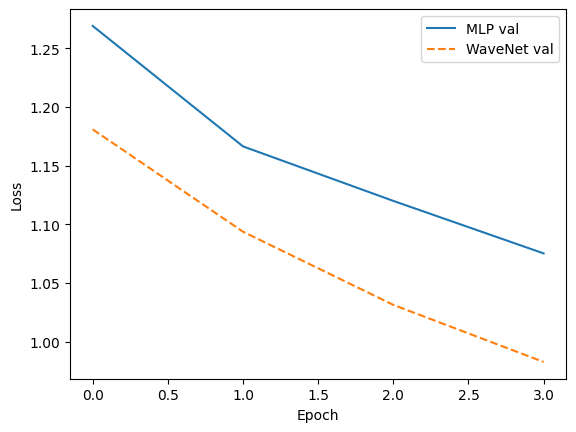

In [23]:
import matplotlib.pyplot as plt
plt.plot(mlp_val, label="MLP val")
plt.plot(wn_val, label="WaveNet val", linestyle="--")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()